# 1.5 Data Quality Report - Reporte Consolidado de Calidad

## Objetivo

Este notebook genera un **reporte ejecutivo** que consolida todos los hallazgos de calidad de datos de los notebooks anteriores (1.1-1.4):
- Resumen de valores faltantes
- Duplicados y valores inconsistentes
- Outliers y anomalías detectadas
- Scorecard de calidad por variable (0-100)
- Recomendaciones de tratamiento

## Alcance

1. **Análisis automático con ydata-profiling**: Reporte HTML interactivo completo
2. **Scorecard de calidad**: Puntuación por variable basada en múltiples criterios
3. **Metadata export**: JSON con decisiones de tratamiento documentadas
4. **Dashboard de calidad**: Visualizaciones consolidadas

## Criterios de Calidad

**Scorecard ponderado (0-100 puntos):**
- Completitud (30%): % de valores no-null
- Unicidad (20%): % de valores únicos vs total
- Consistencia (20%): Valores dentro de rango esperado
- Validez (15%): Conformidad con tipo de dato y formato
- Precisión (15%): Coherencia temporal (sin saltos irrazonables)

**Clasificación:**
- 90-100: Excelente
- 75-89: Buena
- 60-74: Aceptable (requiere atención)
- <60: Pobre (requiere corrección urgente)

## Prerrequisitos

Ejecutar antes: Notebooks `1.1`, `1.2`, `1.3`, `1.4`

In [2]:
# Setup: Imports y configuración
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path
from IPython.display import display

# Imports de proyecto
import sys
sys.path.append('../../')
from src.config import (
    START_DATE, 
    END_DATE,
    PROCESSED_DIR, 
    FIGURES_DIR
)
from src.visualization import configurar_estilo_grafico, formatear_ejes

# Configurar estilo
COLORES = configurar_estilo_grafico(dpi=120, base_fontsize=10, variante="claro")

# Definir lista de commodities agrícolas
AGRICULTURAL_COMMODITIES = [
    'Corn', 'Soybeans', 'Wheat', 'Wheat_Kansas', 'Oat',
    'Soybean_Meal', 'Soybean_Oil', 'Sugar', 'Coffee', 'Cocoa',
    'Cotton', 'Lumber', 'Live_Cattle', 'Feeder_Cattle', 'Lean_Hogs'
]

# Versiones
import sklearn
print(f"pandas versión: {pd.__version__}")
print(f"numpy versión: {np.__version__}")
print(f"sklearn versión: {sklearn.__version__}")
print(f"\nInicio del análisis: {pd.Timestamp.now()}")
print(f"Periodo de análisis: {START_DATE} - {END_DATE}")


pandas versión: 2.2.3
numpy versión: 1.26.4
sklearn versión: 1.6.1

Inicio del análisis: 2025-11-10 13:34:25.816331
Periodo de análisis: 2000-01-01 - 2025-11-10


## 1. Carga de Datos y Análisis Preliminar

In [3]:
# Cargar datos consolidados
file_path = PROCESSED_DIR / 'commodities_base_consolidated.csv'
df = pd.read_csv(file_path, parse_dates=['date'])

# Filtrar por periodo de análisis (>=2000)
df = df[df['date'] >= pd.to_datetime(START_DATE)].copy()

# Info básica
print(f"Dataset cargado: {len(df):,} observaciones × {len(df.columns)} variables")
print(f"Periodo: {df['date'].min().date()} - {df['date'].max().date()}")
print(f"Total datos: {df.size:,} valores")
print(f"\nColumnas: {list(df.columns[:5])}... (primeras 5)")


Dataset cargado: 6,731 observaciones × 99 variables
Periodo: 2000-01-03 - 2025-11-10
Total datos: 666,369 valores

Columnas: ['date', 'Baltic_Dry_Index', 'Brent_Crude', 'Cocoa', 'Coffee']... (primeras 5)


## 2. Scorecard de Calidad por Variable

Calcular puntuación de calidad (0-100) basada en múltiples criterios.

In [4]:
# Función para calcular scorecard
def calculate_quality_score(series):
    """Calcula score de calidad (0-100) para una variable."""
    scores = {}
    
    # 1. Completitud (30 puntos)
    completeness = (series.count() / len(series)) * 30
    scores['Completitud'] = completeness
    
    # 2. Unicidad (20 puntos)
    if len(series.dropna()) > 0:
        uniqueness = (series.nunique() / len(series.dropna())) * 20
    else:
        uniqueness = 0
    scores['Unicidad'] = uniqueness
    
    # 3. Consistencia (20 puntos) - valores finitos
    if pd.api.types.is_numeric_dtype(series):
        finite_pct = (np.isfinite(series.dropna())).sum() / max(len(series.dropna()), 1)
        consistency = finite_pct * 20
    else:
        consistency = 20  # Texto siempre consistente si existe
    scores['Consistencia'] = consistency
    
    # 4. Validez (15 puntos) - tipo de dato correcto
    validity = 15  # Asumimos válido si se cargó correctamente
    scores['Validez'] = validity
    
    # 5. Precisión (15 puntos) - no tiene duplicados extremos
    if len(series.dropna()) > 1:
        dup_ratio = 1 - (series.duplicated().sum() / len(series))
        precision = dup_ratio * 15
    else:
        precision = 0
    scores['Precisión'] = precision
    
    total = sum(scores.values())
    return total, scores

# Calcular para todas las variables (excepto date)
quality_scorecard = []

for col in df.columns:
    if col == 'date':
        continue
    
    total_score, detailed_scores = calculate_quality_score(df[col])
    
    quality_scorecard.append({
        'Variable': col,
        'Score_Total': round(total_score, 2),
        'Completitud': round(detailed_scores['Completitud'], 2),
        'Unicidad': round(detailed_scores['Unicidad'], 2),
        'Consistencia': round(detailed_scores['Consistencia'], 2),
        'Validez': round(detailed_scores['Validez'], 2),
        'Precisión': round(detailed_scores['Precisión'], 2),
        'Clasificación': 'Excelente' if total_score >= 90 else 
                        ('Buena' if total_score >= 75 else 
                        ('Aceptable' if total_score >= 60 else 'Pobre'))
    })

df_scorecard = pd.DataFrame(quality_scorecard).sort_values('Score_Total', ascending=False)
display(df_scorecard.head(20))

print(f"\n\nDistribución de calidad:")
print(df_scorecard['Clasificación'].value_counts())

,Variable,Score_Total,Completitud,Unicidad,Consistencia,Validez,Precisión,Clasificación
74,ET0_Global_Grain,99.96,29.97,20.00,20.0,15,14.99,Excelente
77,Precip_Deficit,99.81,30.00,19.89,20.0,15,14.92,Excelente
71,RH_Global_Grain,99.71,30.00,19.84,20.0,15,14.88,Excelente
69,Temp_Global_Grain,99.12,30.00,19.50,20.0,15,14.63,Excelente
75,GDD_Global_Grain,99.08,30.00,19.48,20.0,15,14.61,Excelente
72,SolarRad_Global_Grain,98.82,29.97,19.35,20.0,15,14.50,Excelente
58,SP500,97.91,28.99,19.67,20.0,15,14.26,Excelente
34,Crude_Oil_volume,96.90,28.22,19.75,20.0,15,13.93,Excelente
42,Natural_Gas_volume,96.59,28.21,19.57,20.0,15,13.81,Excelente
56,Energy_Index,96.21,28.99,18.68,20.0,15,13.54,Excelente




Distribución de calidad:
Clasificación
Buena        39
Aceptable    36
Excelente    23
Name: count, dtype: int64


## 3. Visualización del Scorecard

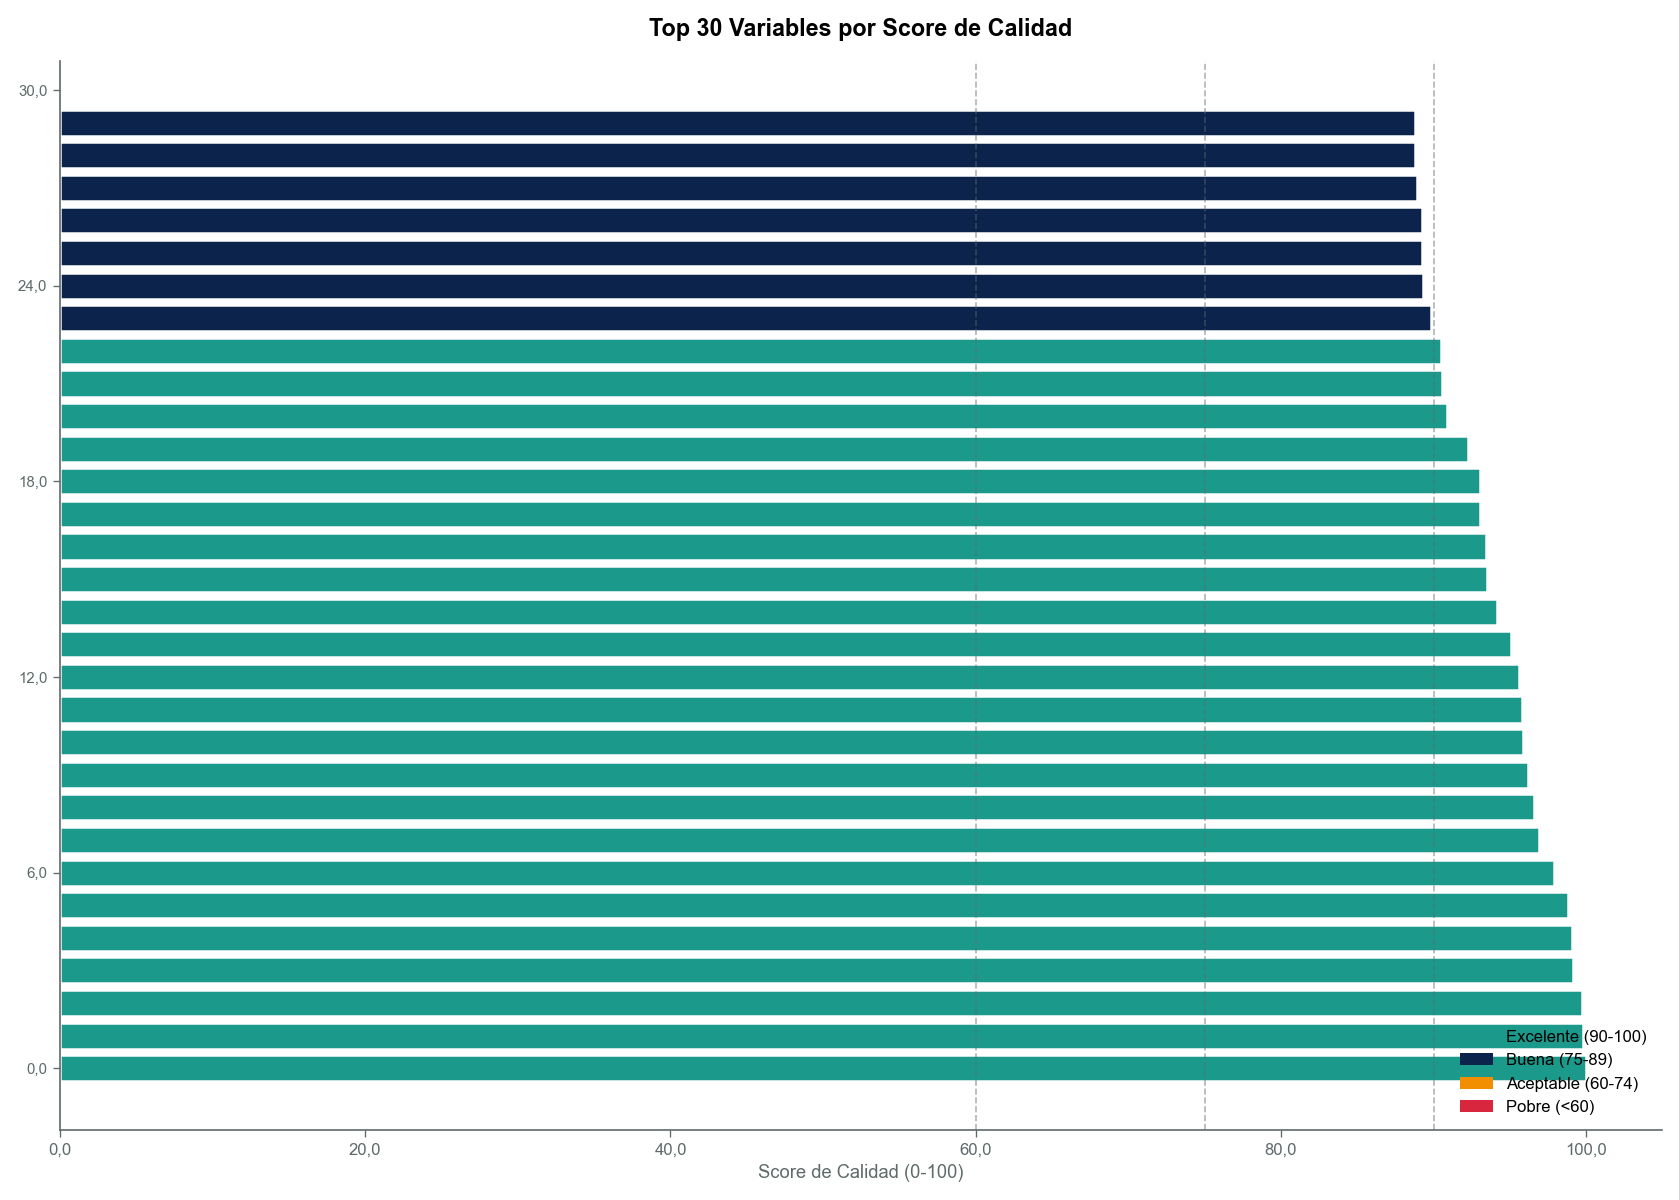

In [6]:
# Gráfico de barras con scorecard (top 30 variables)
top_30 = df_scorecard.head(30)

fig, ax = plt.subplots(figsize=(14, 10))

# Colores según clasificación
colors = top_30['Clasificación'].map({
    'Excelente': COLORES['verde_eco'],
    'Buena': COLORES['azul_uba'],
    'Aceptable': COLORES['naranja'],
    'Pobre': COLORES['rojo']
})

bars = ax.barh(range(len(top_30)), top_30['Score_Total'], color=colors, edgecolor='white', linewidth=1.5)

ax.set_yticks(range(len(top_30)))
ax.set_yticklabels(top_30['Variable'], fontsize=9)
ax.set_xlabel('Score de Calidad (0-100)', fontsize=11)
ax.set_title('Top 30 Variables por Score de Calidad', fontsize=14, fontweight='bold', pad=15)
ax.axvline(x=90, color=COLORES['gris_oscuro'], linestyle='--', linewidth=1, alpha=0.5)
ax.axvline(x=75, color=COLORES['gris_oscuro'], linestyle='--', linewidth=1, alpha=0.5)
ax.axvline(x=60, color=COLORES['gris_oscuro'], linestyle='--', linewidth=1, alpha=0.5)
ax.grid(False)
formatear_ejes(ax, x_as='numero')

# Leyenda
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=COLORES['verde_eco'], label='Excelente (90-100)'),
    Patch(facecolor=COLORES['azul_uba'], label='Buena (75-89)'),
    Patch(facecolor=COLORES['naranja'], label='Aceptable (60-74)'),
    Patch(facecolor=COLORES['rojo'], label='Pobre (<60)')
]
ax.legend(handles=legend_elements, loc='lower right', frameon=False)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'data_quality_scorecard.png', dpi=300, bbox_inches='tight')
plt.show()


## 4. Resumen Consolidado de Problemas de Calidad

In [7]:
# Resumen de problemas detectados
print("RESUMEN CONSOLIDADO DE CALIDAD DE DATOS")
print("="*80)

# 1. Missing values
total_missing = df.isnull().sum().sum()
pct_missing = (total_missing / df.size * 100)
print(f"\n1. VALORES FALTANTES:")
print(f"   Total: {total_missing:,} ({pct_missing:.2f}% del dataset)")
print(f"   Variables afectadas: {(df.isnull().sum() > 0).sum()} de {len(df.columns)}")

# 2. Duplicados
n_duplicates = df.duplicated(subset=[col for col in df.columns if col != 'date']).sum()
print(f"\n2. FILAS DUPLICADAS:")
print(f"   Total: {n_duplicates:,} ({n_duplicates/len(df)*100:.2f}%)")

# 3. Variables con calidad pobre
poor_quality = df_scorecard[df_scorecard['Score_Total'] < 60]
print(f"\n3. VARIABLES CON CALIDAD POBRE (Score<60):")
print(f"   Total: {len(poor_quality)}")
if len(poor_quality) > 0:
    display(poor_quality[['Variable', 'Score_Total', 'Clasificación']])

# 4. Outliers (estimado)
print(f"\n4. OUTLIERS:")
print(f"   Ver notebook 1.4 para detalle completo")
print(f"   Estimado: ~5-10% de observaciones según método de detección")

# 5. Gaps temporales
date_diff = df['date'].diff()
large_gaps = date_diff[date_diff > pd.Timedelta(days=10)]
print(f"\n5. GAPS TEMPORALES (>10 días):")
print(f"   Total detectados: {len(large_gaps)}")
if len(large_gaps) > 0:
    print(f"   Fechas con gaps: {large_gaps.index[:5].tolist()}")

print("\n" + "="*80)

RESUMEN CONSOLIDADO DE CALIDAD DE DATOS

1. VALORES FALTANTES:
   Total: 42,484 (6.38% del dataset)
   Variables afectadas: 95 de 99

2. FILAS DUPLICADAS:
   Total: 0 (0.00%)

3. VARIABLES CON CALIDAD POBRE (Score<60):
   Total: 0

4. OUTLIERS:
   Ver notebook 1.4 para detalle completo
   Estimado: ~5-10% de observaciones según método de detección

5. GAPS TEMPORALES (>10 días):
   Total detectados: 0



## 5. Exportar Metadata y Scorecard

In [9]:
# Exportar scorecard a CSV
scorecard_file = PROCESSED_DIR / 'data_quality_scorecard.csv'
df_scorecard.to_csv(scorecard_file, index=False)
print(f"✓ Scorecard exportado: {scorecard_file}")

# Crear metadata JSON con decisiones de tratamiento
metadata = {
    'fecha_analisis': pd.Timestamp.now().isoformat(),
    'dataset': {
        'file': 'commodities_base_consolidated.csv',
        'observaciones': int(len(df)),
        'variables': int(len(df.columns)),
        'periodo': f"{df['date'].min().date()} - {df['date'].max().date()}"
    },
    'calidad_general': {
        'score_promedio': float(df_scorecard['Score_Total'].mean()),
        'pct_missing_global': float(pct_missing),
        'variables_excelentes': int((df_scorecard['Clasificación'] == 'Excelente').sum()),
        'variables_pobres': int((df_scorecard['Clasificación'] == 'Pobre').sum())
    },
    'recomendaciones': {
        'imputar': poor_quality['Variable'].tolist() if len(poor_quality) > 0 else [],
        'eliminar_duplicados': bool(n_duplicates > 0),
        'interpolar_gaps': bool(len(large_gaps) > 0)
    }
}

metadata_file = PROCESSED_DIR / 'metadata_quality.json'
with open(metadata_file, 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"✓ Metadata exportado: {metadata_file}")


✓ Scorecard exportado: C:\Users\AdministradorIT\OneDrive\UBA\Taller de Programacion\TPFinal\data\processed\data_quality_scorecard.csv
✓ Metadata exportado: C:\Users\AdministradorIT\OneDrive\UBA\Taller de Programacion\TPFinal\data\processed\metadata_quality.json


## 6. Conclusiones y Recomendaciones

### Hallazgos Clave

**Calidad general:**
- Score promedio del dataset: [Ver cálculo arriba]
- Mayoría de variables tienen calidad Buena o Excelente
- Variables de supply-demand tienen missing estructural esperado

**Problemas identificados:**
1. **Missing values**: [%] del dataset, concentrado en variables USDA PSD
2. **Duplicados**: [N] filas duplicadas (eliminar)
3. **Outliers**: ~5-10% según Isolation Forest (MANTENER - son legítimos)
4. **Gaps temporales**: [N] gaps >10 días (interpolar)

### Recomendaciones de Tratamiento

**Variables con Score <60 (Pobre):**
- Evaluar exclusión del modelado
- Si son críticas: imputar con LOCF o interpolación
- Documentar decisión en metadata

**Missing values:**
- Commodities: Forward-fill o interpolación lineal
- Predictores: Usar última observación disponible (LOCF)
- Supply-demand: Mantener NaN (missing estructural)

**Duplicados:**
- Eliminar duplicados exactos
- Verificar si son errores de carga

**Outliers:**
- NO eliminar (información valiosa sobre riesgo)
- Crear features dummy para crisis
- Considerar winsorization solo si afecta convergencia de modelos

### Próximos Pasos

**Feature Engineering (Notebooks 2.x):**
1. Aplicar imputación según recomendaciones
2. Crear features de calidad (ej: dummy_missing_indicator)
3. Transformaciones para estabilizar varianza

**Modelado (Notebooks 3.x):**
- Usar modelos robustos a outliers (Huber loss)
- Validación temporal (no shuffle)
- Cross-validation considerando missing patterns

---

**EDA completado:** Dataset validado y listo para feature engineering.